# NiVScan — Model D: `cahya/bert-base-indonesian-NER`

---

| | |
|---|---|
| **Mata Kuliah** | COMP6885001 — Natural Language Processing |
| **Model** | `cahya/bert-base-indonesian-NER` (IndoBERT, Bahasa Indonesia) |
| **Task** | Named Entity Recognition — DISEASE, SYMPTOM, LOCATION |
| **Runtime** | GPU (T4 Colab) |
| **Input** | `dataset_train_iob.json`, `dataset_val_iob.json`, `dataset_test_iob.json` |
| **Output** | `model_D_final/` (checkpoint terbaik) |

---

## Baca Dulu!
- Pastikan **Runtime → Change runtime type → T4 GPU** sebelum jalankan
- Step 0 dan Step 1 harus sudah selesai (file IOB sudah ada di Drive)
- Setiap epoch otomatis disimpan ke Drive — aman kalau Colab disconnect
- Early stopping aktif — training otomatis berhenti kalau val F1 tidak improve

## Catatan Model D
Model `cahya/bert-base-indonesian-NER` adalah BERT yang di-pre-train khusus untuk Bahasa Indonesia.
Diharapkan lebih baik untuk teks berbahasa Indonesia, namun mungkin lebih lemah untuk teks berbahasa Inggris.
Dataset kalian campuran ID+EN, jadi hasilnya menarik untuk dibandingkan dengan Model B dan C.

In [1]:
# Cek GPU tersedia
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM           : {total_mem:.1f} GB')
else:
    print('GPU tidak terdeteksi!')
    print('   → Ganti runtime: Runtime → Change runtime type → T4 GPU')

CUDA available : True
GPU            : Tesla T4
VRAM           : 14.6 GB


In [4]:
!pip install -q transformers datasets seqeval accelerate
print('Library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Library berhasil diinstall!


In [5]:
import os
import json
import numpy as np
import pandas as pd
from collections import Counter

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorForTokenClassification
)
from datasets import Dataset
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
print(f'   transformers : {__import__("transformers").__version__}')
print(f'   torch        : {torch.__version__}')

   transformers : 5.0.0
   torch        : 2.10.0+cu128


---
## 2. Mount Google Drive & Set Path

In [6]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive berhasil terhubung!')

Mounted at /content/drive
Google Drive berhasil terhubung!


In [7]:
BASE_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset'
MODEL_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D'

PATH_TRAIN_IOB = f'{BASE_PATH}/dataset_train_iob.json'
PATH_VAL_IOB   = f'{BASE_PATH}/dataset_val_iob.json'
PATH_TEST_IOB  = f'{BASE_PATH}/dataset_test_iob.json'

# Buat folder model kalau belum ada
os.makedirs(MODEL_PATH, exist_ok=True)

print('Path dataset:')
print(f'   Train : {PATH_TRAIN_IOB}')
print(f'   Val   : {PATH_VAL_IOB}')
print(f'   Test  : {PATH_TEST_IOB}')
print(f'   Model : {MODEL_PATH}')

Path dataset:
   Train : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/dataset_train_iob.json
   Val   : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/dataset_val_iob.json
   Test  : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Dataset/dataset_test_iob.json
   Model : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D


---
## 3. Load Dataset IOB

In [8]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

for p in [PATH_TRAIN_IOB, PATH_VAL_IOB, PATH_TEST_IOB]:
    assert os.path.exists(p), f'File tidak ditemukan: {p}\n   → Jalankan Step 1 terlebih dahulu!'

train_data = load_json(PATH_TRAIN_IOB)
val_data   = load_json(PATH_VAL_IOB)
test_data  = load_json(PATH_TEST_IOB)

print('Dataset IOB berhasil diload!')
print(f'   Train : {len(train_data)} kalimat')
print(f'   Val   : {len(val_data)} kalimat')
print(f'   Test  : {len(test_data)} kalimat')
print()
print('Contoh 1 item train:')
sample = train_data[0]
for tok, tag in zip(sample['tokens'], sample['ner_tags']):
    print(f'   {tok:25s} → {tag}')

Dataset IOB berhasil diload!
   Train : 574 kalimat
   Val   : 144 kalimat
   Test  : 179 kalimat

Contoh 1 item train:
   No                        → O
   infection                 → O
   of                        → O
   humans                    → O
   or                        → O
   other                     → O
   species                   → O
   has                       → O
   been                      → O
   observed                  → O
   in                        → O
   Cambodia                  → B-LOCATION
   ,                         → O
   Thailand                  → B-LOCATION
   ,                         → O
   or                        → O
   Africa                    → B-LOCATION
   as                        → O
   of                        → O
   May                       → O
   2018                      → O
   .                         → O


---
## 4. Label Mapping

In [9]:
# Kumpulkan semua label unik dari train + val + test
all_tags = set()
for split in [train_data, val_data, test_data]:
    for item in split:
        all_tags.update(item['ner_tags'])

# Urutkan: O dulu, lalu B- dan I- secara alfabetis
label_list = sorted(all_tags, key=lambda x: (x != 'O', x))

label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

print(f'Label mapping berhasil dibuat!')
print(f'   Total label : {len(label_list)}')
print()
for label, idx in label2id.items():
    print(f'   {idx} → {label}')

Label mapping berhasil dibuat!
   Total label : 7

   0 → O
   1 → B-DISEASE
   2 → B-LOCATION
   3 → B-SYMPTOM
   4 → I-DISEASE
   5 → I-LOCATION
   6 → I-SYMPTOM


---
## 5. Tokenisasi & Alignment Label

BERT menggunakan WordPiece tokenizer — satu kata bisa dipecah jadi beberapa subword token.
Contoh: `"Malaysia"` → `["Mal", "##aysia"]`

Label hanya diberikan ke token pertama dari setiap kata (`-100` untuk subword berikutnya
supaya tidak ikut dihitung saat evaluasi).

In [10]:
MODEL_NAME = 'cahya/bert-base-indonesian-NER'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer berhasil diload: {MODEL_NAME}')
print(f'   Vocab size     : {tokenizer.vocab_size}')
print(f'   Max length     : {tokenizer.model_max_length}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer berhasil diload: cahya/bert-base-indonesian-NER
   Vocab size     : 32000
   Max length     : 1000000000000000019884624838656


In [11]:
def tokenize_and_align_labels(examples):
    """
    Tokenisasi dengan WordPiece dan align label ke subword tokens.
    Subword token ke-2 dst dari 1 kata diberi label -100 (diabaikan saat loss/eval).
    """
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        max_length=128,          # cukup untuk kalimat Nipah
        is_split_into_words=True # input sudah berupa list token
    )

    all_labels = []
    for i, label_seq in enumerate(examples['ner_tags']):
        word_ids     = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        aligned      = []

        for word_id in word_ids:
            if word_id is None:
                # Token spesial [CLS] dan [SEP]
                aligned.append(-100)
            elif word_id != prev_word_id:
                # Token pertama dari sebuah kata → pakai label asli
                aligned.append(label2id[label_seq[word_id]])
            else:
                # Subword berikutnya → -100 (diabaikan)
                aligned.append(-100)
            prev_word_id = word_id

        all_labels.append(aligned)

    tokenized['labels'] = all_labels
    return tokenized


print('Fungsi tokenisasi berhasil didefinisikan!')
print()

# Test dengan 1 contoh
sample = train_data[0]
test_enc = tokenizer(
    sample['tokens'],
    is_split_into_words=True,
    max_length=128,
    truncation=True
)
print('Test tokenisasi (5 token pertama):')
for token_id, word_id in zip(test_enc['input_ids'][:7], test_enc.word_ids()[:7]):
    decoded = tokenizer.decode([token_id])
    print(f'   token_id={token_id:6d}  word_id={str(word_id):4s}  decoded={decoded}')

Fungsi tokenisasi berhasil didefinisikan!

Test tokenisasi (5 token pertama):
   token_id=     3  word_id=None  decoded=[CLS]
   token_id=  2845  word_id=0     decoded=no
   token_id=  2512  word_id=1     decoded=inf
   token_id= 12697  word_id=1     decoded=##ection
   token_id=  2077  word_id=2     decoded=of
   token_id=  9603  word_id=3     decoded=human
   token_id=  1018  word_id=3     decoded=##s


In [12]:
# Konversi ke HuggingFace Dataset
def to_hf_dataset(data):
    return Dataset.from_dict({
        'tokens'  : [d['tokens']   for d in data],
        'ner_tags': [d['ner_tags'] for d in data],
        'id'      : [d['id']       for d in data],
    })

train_hf = to_hf_dataset(train_data)
val_hf   = to_hf_dataset(val_data)
test_hf  = to_hf_dataset(test_data)

# Tokenisasi semua split
print('Tokenisasi dataset...')
train_enc = train_hf.map(tokenize_and_align_labels, batched=True, remove_columns=['tokens','ner_tags','id'])
val_enc   = val_hf.map(tokenize_and_align_labels,   batched=True, remove_columns=['tokens','ner_tags','id'])
test_enc  = test_hf.map(tokenize_and_align_labels,  batched=True, remove_columns=['tokens','ner_tags','id'])

print('Tokenisasi selesai!')
print(f'   Train : {len(train_enc)} samples')
print(f'   Val   : {len(val_enc)} samples')
print(f'   Test  : {len(test_enc)} samples')

Tokenisasi dataset...


Map:   0%|          | 0/574 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Map:   0%|          | 0/179 [00:00<?, ? examples/s]

Tokenisasi selesai!
   Train : 574 samples
   Val   : 144 samples
   Test  : 179 samples


---
## 6. Load Model

In [13]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # head classifier diganti sesuai label kita
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model berhasil diload: {MODEL_NAME}')
print(f'   Device           : {device}')
print(f'   Total params     : {total_params:,}')
print(f'   Trainable params : {trainable_params:,}')
print(f'   Num labels       : {len(label_list)}')

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |                                                                                      
-----------------------------+------------+--------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                      
bert.pooler.dense.weight     | UNEXPECTED |                                                                                      
bert.pooler.dense.bias       | UNEXPECTED |                                                                                      
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([39]) vs model:torch.Size([7])          
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([39, 768]) vs model:torch.Size([7, 768])

Notes:
- UNEX

Model berhasil diload: cahya/bert-base-indonesian-NER
   Device           : cuda
   Total params     : 110,032,135
   Trainable params : 110,032,135
   Num labels       : 7


---
## 7. Training Configuration

Konfigurasi dioptimalkan untuk GPU T4 (16GB VRAM):
- **Batch size 32** — maksimal untuk T4 dengan BERT-base dan max_length=128
- **Gradient accumulation 2** — efektif batch size = 64
- **Checkpoint tiap epoch** — langsung disimpan ke Drive
- **Early stopping patience=3** — stop kalau val F1 tidak naik 3 epoch berturut-turut
- **load_best_model_at_end=True** — otomatis load checkpoint terbaik di akhir

In [14]:
def compute_metrics(eval_pred):
    """Hitung Precision, Recall, F1 menggunakan seqeval (entity-level)."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)

    true_labels = []
    true_preds  = []

    for pred_seq, label_seq in zip(predictions, labels):
        true_label_row = []
        true_pred_row  = []
        for pred, label in zip(pred_seq, label_seq):
            if label == -100:
                continue  # skip subword tokens dan special tokens
            true_label_row.append(id2label[label])
            true_pred_row.append(id2label[pred])
        true_labels.append(true_label_row)
        true_preds.append(true_pred_row)

    return {
        'precision': precision_score(true_labels, true_preds),
        'recall'   : recall_score(true_labels, true_preds),
        'f1'       : f1_score(true_labels, true_preds),
    }

print('Fungsi compute_metrics berhasil didefinisikan!')

Fungsi compute_metrics berhasil didefinisikan!


In [15]:
CHECKPOINT_DIR = f'{MODEL_PATH}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir                  = CHECKPOINT_DIR,

    # ── Batch & Epoch ──────────────────────────────────────
    num_train_epochs            = 50,          # max epoch, early stopping yang atur
    per_device_train_batch_size = 32,          # optimal untuk T4 + BERT-base
    per_device_eval_batch_size  = 64,          # eval bisa lebih besar (no gradient)
    gradient_accumulation_steps = 2,           # effective batch = 64

    # ── Checkpoint — simpan tiap epoch ke Drive ────────────
    save_strategy               = 'epoch',
    save_total_limit            = 3,           # simpan 3 checkpoint terbaik saja

    # ── Evaluasi ──────────────────────────────────────────
    eval_strategy               = 'epoch',
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    load_best_model_at_end      = True,        # otomatis load checkpoint terbaik

    # ── Learning Rate ─────────────────────────────────────
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,

    # ── Optimasi GPU ──────────────────────────────────────
    fp16                        = True,        # mixed precision — hemat VRAM ~30%
    gradient_checkpointing      = True,        # hemat VRAM saat backprop
    dataloader_num_workers      = 2,

    # ── Logging ───────────────────────────────────────────
    logging_dir                 = f'{MODEL_PATH}/logs',
    logging_steps               = 10,
    report_to                   = 'none',      # matikan wandb
)

print('Training arguments berhasil dikonfigurasi!')
print(f'   Batch size per device   : {training_args.per_device_train_batch_size}')
print(f'   Gradient accumulation   : {training_args.gradient_accumulation_steps}')
print(f'   Effective batch size    : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'   Max epochs              : {training_args.num_train_epochs}')
print(f'   FP16 mixed precision    : {training_args.fp16}')
print(f'   Gradient checkpointing  : {training_args.gradient_checkpointing}')
print(f'   Early stopping patience : 3 epoch')
print(f'   Checkpoint dir          : {CHECKPOINT_DIR}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments berhasil dikonfigurasi!
   Batch size per device   : 32
   Gradient accumulation   : 2
   Effective batch size    : 64
   Max epochs              : 50
   FP16 mixed precision    : True
   Gradient checkpointing  : True
   Early stopping patience : 3 epoch
   Checkpoint dir          : /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D/checkpoints


In [16]:
data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_enc,
    eval_dataset    = val_enc,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(
            early_stopping_patience  = 3,    # stop kalau 3 epoch tidak improve
            early_stopping_threshold = 0.001 # minimal improvement 0.1%
        )
    ]
)

print('Trainer berhasil dikonfigurasi!')

Trainer berhasil dikonfigurasi!


---
## 8. Training

In [17]:
print('Memulai training...')
print('   Checkpoint disimpan ke Drive tiap epoch.')
print('   Training akan otomatis berhenti kalau val F1 tidak naik 3 epoch berturut-turut.')
print()

train_result = trainer.train()

print()
print('Training selesai!')
print(f'   Total steps  : {train_result.global_step}')
print(f'   Training loss: {train_result.training_loss:.4f}')

Memulai training...
   Checkpoint disimpan ke Drive tiap epoch.
   Training akan otomatis berhenti kalau val F1 tidak naik 3 epoch berturut-turut.



Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,1.204273,0.054598,0.135714,0.077869
2,3.353922,0.347707,0.000000,0.000000,0.000000
3,1.326592,0.182851,0.576087,0.378571,0.456897
4,0.475280,0.119820,0.795082,0.692857,0.740458
5,0.289289,0.092889,0.801653,0.692857,0.743295
6,0.197620,0.072933,0.902655,0.728571,0.806324
7,0.102209,0.060146,0.870229,0.814286,0.841328
8,0.081130,0.060419,0.884615,0.821429,0.851852
9,0.052571,0.064095,0.848276,0.878571,0.863158
10,0.037986,0.059277,0.877698,0.871429,0.874552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training selesai!
   Total steps  : 135
   Training loss: 0.4431


---
## 9. Simpan Model Final ke Drive

In [18]:
FINAL_MODEL_PATH = f'{MODEL_PATH}/model_D_final'
os.makedirs(FINAL_MODEL_PATH, exist_ok=True)

# Simpan model terbaik (sudah di-load otomatis karena load_best_model_at_end=True)
trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)

print(f'Model final berhasil disimpan!')
print(f'   Path: {FINAL_MODEL_PATH}')
print()

# Cek ukuran file
total_size = 0
for f in os.listdir(FINAL_MODEL_PATH):
    fpath = os.path.join(FINAL_MODEL_PATH, f)
    size  = os.path.getsize(fpath)
    total_size += size
    print(f'   {f:40s} {size/1024**2:.1f} MB')
print(f'   {"TOTAL":40s} {total_size/1024**2:.1f} MB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model final berhasil disimpan!
   Path: /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D/model_D_final

   config.json                              0.0 MB
   model.safetensors                        419.8 MB
   tokenizer_config.json                    0.0 MB
   tokenizer.json                           0.7 MB
   training_args.bin                        0.0 MB
   TOTAL                                    420.5 MB


---
## 10. Evaluasi Final di `dataset_test_iob.json`

In [19]:
print('Evaluasi di test set (100 kalimat ANNOTATED_DATA)...')

predictions, labels, _ = trainer.predict(test_enc)
preds = np.argmax(predictions, axis=-1)

true_labels = []
true_preds  = []

for pred_seq, label_seq in zip(preds, labels):
    true_label_row = []
    true_pred_row  = []
    for pred, label in zip(pred_seq, label_seq):
        if label == -100:
            continue
        true_label_row.append(id2label[label])
        true_pred_row.append(id2label[pred])
    true_labels.append(true_label_row)
    true_preds.append(true_pred_row)

print()
print('=' * 62)
print('  EVALUASI MODEL B — cahya/bert-base-indonesian-NER')
print('  Test set: dataset_test_iob.json (100 kalimat manual)')
print('=' * 62)
print()
print(classification_report(true_labels, true_preds))

Evaluasi di test set (100 kalimat ANNOTATED_DATA)...



  EVALUASI MODEL B — cahya/bert-base-indonesian-NER
  Test set: dataset_test_iob.json (100 kalimat manual)

              precision    recall  f1-score   support

     DISEASE       0.92      0.95      0.93        94
    LOCATION       0.74      0.61      0.67        69
     SYMPTOM       0.57      0.50      0.53         8

   micro avg       0.84      0.79      0.81       171
   macro avg       0.74      0.69      0.71       171
weighted avg       0.83      0.79      0.81       171



In [20]:
from seqeval.metrics import classification_report as seq_report
import numpy as np

def convert_numpy_to_python(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

macro_p  = precision_score(true_labels, true_preds)
macro_r  = recall_score(true_labels, true_preds)
macro_f1 = f1_score(true_labels, true_preds)

eval_results = {
    'model'    : 'Model D — cahya/bert-base-indonesian-NER',
    'test_set' : 'dataset_test_iob.json (100 kalimat manual)',
    'macro': {
        'precision': round(float(macro_p), 4),
        'recall'   : round(float(macro_r), 4),
        'f1'       : round(float(macro_f1), 4)
    },
    'per_entity': seq_report(true_labels, true_preds, output_dict=True)
}

RESULT_PATH = f'{MODEL_PATH}/eval_results_model_D.json'
with open(RESULT_PATH, 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2, default=convert_numpy_to_python)

print('Hasil evaluasi disimpan!')
print(f'   Path: {RESULT_PATH}')
print()
print('Ringkasan Macro Average:')
print(f'   Precision : {macro_p:.4f}')
print(f'   Recall    : {macro_r:.4f}')
print(f'   F1 Score  : {macro_f1:.4f}')

Hasil evaluasi disimpan!
   Path: /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D/eval_results_model_D.json

Ringkasan Macro Average:
   Precision : 0.8385
   Recall    : 0.7895
   F1 Score  : 0.8133


In [21]:
print('=' * 62)
print('MODEL B SELESAI!')
print('=' * 62)
print()
print('File yang tersimpan di Drive:')
print(f'   {FINAL_MODEL_PATH}/')
print(f'   {RESULT_PATH}')
print()
print('Hasil untuk tabel komparasi laporan:')
print(f'   Model D (cahya/bert-base-indonesian-NER)')
print(f'   Precision : {macro_p:.4f}')
print(f'   Recall    : {macro_r:.4f}')
print(f'   F1 Score  : {macro_f1:.4f}')
print()
print('Bagikan eval_results_model_D.json ke anggota tim')
print('   untuk disatukan di tabel komparasi akhir.')

MODEL B SELESAI!

File yang tersimpan di Drive:
   /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D/model_D_final/
   /content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_D/eval_results_model_D.json

Hasil untuk tabel komparasi laporan:
   Model D (cahya/bert-base-indonesian-NER)
   Precision : 0.8385
   Recall    : 0.7895
   F1 Score  : 0.8133

Bagikan eval_results_model_D.json ke anggota tim
   untuk disatukan di tabel komparasi akhir.


---

## 11. Visualisasi Evaluasi & Confusion Matrix

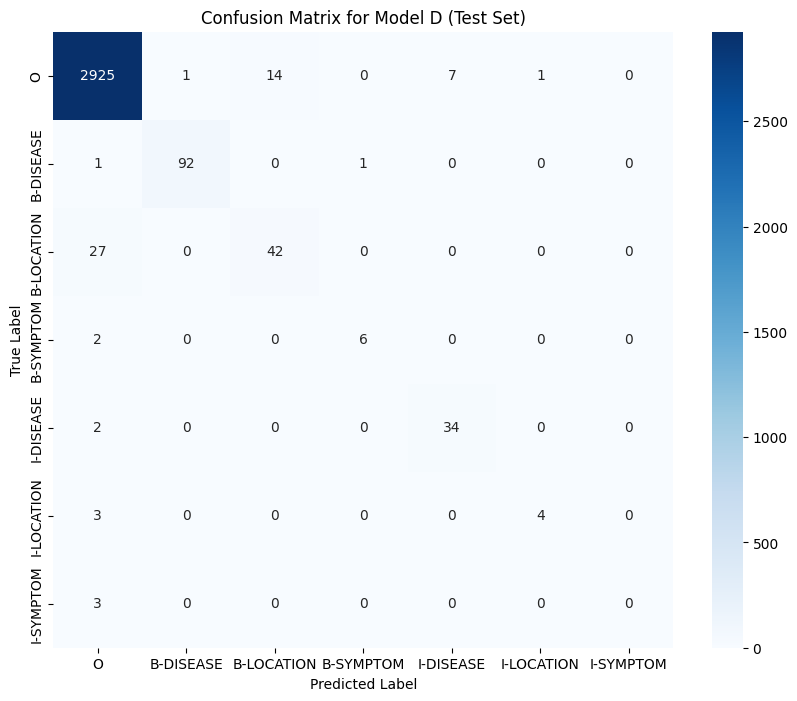

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the true_labels and true_preds for confusion matrix
flat_true_labels = [label for sublist in true_labels for label in sublist]
flat_true_preds  = [pred for sublist in true_preds for pred in sublist]

# Get unique labels from id2label, excluding special tokens if any were missed
# Ensure only actual entity labels and 'O' are considered for the matrix axes
cm_labels = [id2label[i] for i in sorted(id2label.keys()) if id2label[i] != -100]

# Compute confusion matrix
cm = confusion_matrix(flat_true_labels, flat_true_preds, labels=cm_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Model D (Test Set)')
plt.show()

---

## 12. Visualisasi Perbandingan Model (dengan Model B dan C)

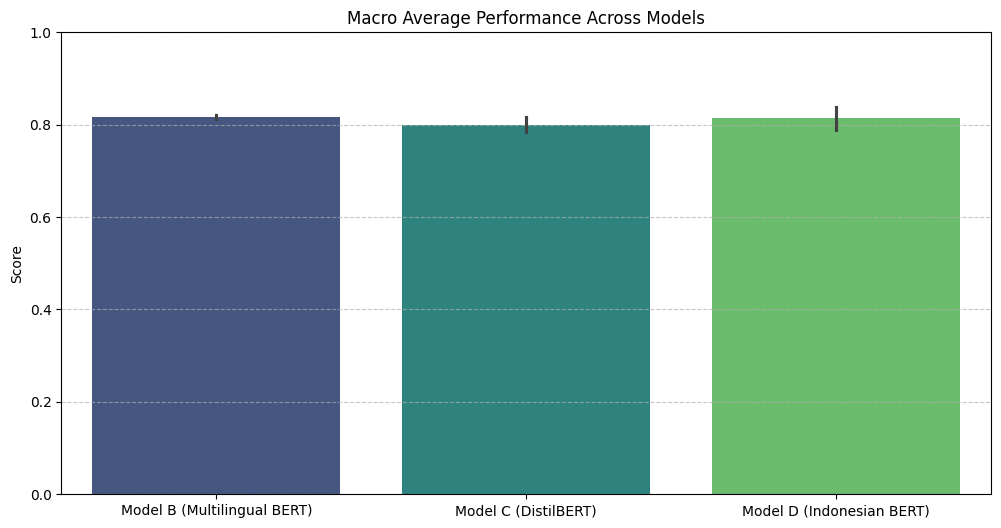

Comparison with Model B and Model C enabled. Please ensure the paths for their evaluation files are correct.


In [25]:
import pandas as pd

# Data for Model D (current model)
model_d_results = eval_results['macro']
model_d_df = pd.DataFrame([model_d_results], index=['Model D (Indonesian BERT)'])[['precision', 'recall', 'f1']]

# Load Model B results
# TODO: Update the path for Model B's evaluation results
MODEL_B_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_B'
with open(f'{MODEL_B_PATH}/eval_results_model_B.json', 'r', encoding='utf-8') as f:
    model_b_eval = json.load(f)
model_b_results = model_b_eval['macro']
model_b_df = pd.DataFrame([model_b_results], index=['Model B (Multilingual BERT)'])[['precision', 'recall', 'f1']]

# Load Model C results
# TODO: Update the path for Model C's evaluation results
MODEL_C_PATH = '/content/drive/MyDrive/Binus University/Semester 4/NLP/NLP-Group Project/Models/model_C'
with open(f'{MODEL_C_PATH}/eval_results_model_C.json', 'r', encoding='utf-8') as f:
    model_c_eval = json.load(f)
model_c_results = model_c_eval['macro']
model_c_df = pd.DataFrame([model_c_results], index=['Model C (DistilBERT)'])[['precision', 'recall', 'f1']]

# Concatenate all model dataframes
all_models_df = pd.concat([model_b_df, model_c_df, model_d_df])

plt.figure(figsize=(12, 6))
sns.barplot(data=all_models_df.transpose(), palette='viridis')
plt.title('Macro Average Performance Across Models')
plt.ylabel('Score')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Comparison with Model B and Model C enabled. Please ensure the paths for their evaluation files are correct.")